# Time Series Analysis by Primary Diagnosis (AutoML)

Time series by primary diagnosis: selection of viable series by temporal density, **AutoML** (FLAML) modeling to choose the best model per series, and export of summaries, charts, and evaluation metrics.

## 1. Import data

**Summary:** Loads the classified Excel, filters to the period 2022-01-01 to 2022-12-31 (365 days), and aggregates counts by **day** and **primary_diagnosis** (disease). Lacunas (dias sem casos) serão preenchidas com média móvel nas etapas seguintes. Output is a daily table (date, doenca, casos) used in the next steps.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from pathlib import Path

ROOT = Path.cwd().resolve()
for _ in range(6):
    if (ROOT / "data").exists() and (ROOT / "notebooks").exists():
        break
    ROOT = ROOT.parent if ROOT.parent != ROOT else ROOT

PATH_INPUT = ROOT / "data" / "results" / "agent_outputs" / "agent_outputs_dataset_sintomas_grupos_classificado.xlsx"
PATH_OUTPUT = ROOT / "data" / "results" / "time_series_outputs"
PATH_SUMMARIES = PATH_OUTPUT / "summaries"
PATH_CHARTS = PATH_OUTPUT / "charts"
os.makedirs(PATH_OUTPUT, exist_ok=True)
os.makedirs(PATH_SUMMARIES, exist_ok=True)
os.makedirs(PATH_CHARTS, exist_ok=True)

DATE_START = "2022-01-01"
DATE_END = "2022-12-31"  # 365 dias no ano
TRAIN_DAYS = 252   # treino = primeiros 252 dias
TEST_DAYS = 113    # teste = últimos 113 dias (252 + 113 = 365)
N_DAYS = 365

df = pd.read_excel(PATH_INPUT, engine="openpyxl")
df["report_created_at"] = pd.to_datetime(df["report_created_at"], errors="coerce")
df = df.dropna(subset=["report_created_at", "primary_diagnosis"])
df = df[(df["report_created_at"] >= DATE_START) & (df["report_created_at"] <= DATE_END)]
df["date"] = df["report_created_at"].dt.normalize()

if "user_id" in df.columns:
    daily = df.groupby(["date", "primary_diagnosis"])["user_id"].nunique().reset_index()
else:
    daily = df.groupby(["date", "primary_diagnosis"]).size().reset_index(name="n")
    daily["user_id"] = daily["n"]
daily.columns = ["date", "doenca", "casos"]

print(f"Registros diários: {len(daily)}")
print(f"Doenças: {daily["doenca"].nunique()}")
daily.head(10)

Registros diários: 3867
Doenças: 86


,date,doenca,casos
0,2022-01-01,Deficiência de glicocorticoide,1
1,2022-01-01,Distrofia muscular,1
2,2022-01-01,Micotemia infecciosa,2
3,2022-01-01,Tosse convulsa,2
4,2022-01-02,Deficiência de glicocorticoide,1
5,2022-01-02,Deficiência enzimática da glicose-6-fosfato de...,2
6,2022-01-02,Fibrose cística,2
7,2022-01-02,Hepatite gordurosa aguda do período de gravide...,1
8,2022-01-02,Hipergamalglobulinemia,1
9,2022-01-02,Hipotireoidismo,1


## 2. Select series with viable density

**Summary:** For each disease, computes **temporal density** (share of days with at least one case) and total cases. Keeps only series with **at least 100 days with data** and minimum total cases (>= 20) so that time series modeling is feasible.

In [2]:
days_full = pd.date_range(start=DATE_START, end=DATE_END, freq="D")
n_days = len(days_full)

density_list = []
for doenca, grp in daily.groupby("doenca"):
    n_days_with_data = grp["date"].nunique()
    total_casos = grp["casos"].sum()
    density = n_days_with_data / n_days if n_days else 0
    density_list.append({"doenca": doenca, "density": density, "total_casos": total_casos, "n_days_with_data": n_days_with_data})

density_df = pd.DataFrame(density_list)
MIN_DAYS = 100  # pelo menos 100 dias com dados para modelar
MIN_CASOS = 20
viable = density_df[(density_df["n_days_with_data"] >= MIN_DAYS) & (density_df["total_casos"] >= MIN_CASOS)]["doenca"].tolist()
print(f"Séries viáveis (>= {MIN_DAYS} dias com dados, total_casos >= {MIN_CASOS}): {len(viable)}")
density_df.sort_values("density", ascending=False).head(15)

Séries viáveis (>= 100 dias com dados, total_casos >= 20): 15


,doenca,density,total_casos,n_days_with_data
56,Micotemia infecciosa,0.575342,1330,210
20,Distrofia muscular,0.520548,660,190
73,Tricomonose,0.504110,568,184
17,Deficiência enzimática da glicose-6-fosfato de...,0.468493,744,171
72,Tosse convulsa,0.463014,443,169
32,Febre do dengue,0.446575,605,163
48,Hipertensão arterial,0.443836,308,162
81,piolho,0.424658,477,155
45,Hipergamalglobulinemia,0.408219,289,149
23,Doença das glândulas salivares,0.394521,439,144


## 3. AutoML modeling (252 dias treino / 113 dias teste)

**Summary:** Séries viáveis têm pelo menos 100 dias com dados. As **lacunas** (dias sem casos) são preenchidas com **média móvel** (janela 7 dias, centralizada). Cada série tem 365 dias: **treino = primeiros 252 dias**, **teste = últimos 113 dias**. **FLAML** (ts_forecast) escolhe o melhor modelo; geração de forecast e métricas (RMSE, MAE, MAPE). Séries de má qualidade (ex.: MAPE alto ou IC95% cruzando zero) são sinalizadas.

In [3]:
from flaml import AutoML
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

def safe_name(s, max_len=50):
    return s.replace("/", "-").replace("\\", "-")[:max_len]

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    mask = y_true != 0
    if not mask.any():
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

automl_results = []
TIME_BUDGET = 90

for i, doenca in enumerate(viable):
    print(f"  [{i+1}/{len(viable)}] {doenca}")
    sub = daily[daily["doenca"] == doenca].set_index("date")["casos"]
    sub.index = pd.DatetimeIndex(sub.index)
    series = sub.reindex(pd.DatetimeIndex(days_full)).fillna(0)
    # Preencher lacunas (dias vazios) com média móvel (janela 7 dias, centralizada)
    mask_gap = (series == 0)
    if mask_gap.any():
        rol = series.rolling(7, min_periods=1, center=True).mean()
        series = series.copy()
        series[mask_gap] = rol[mask_gap]
        # Bordas que ainda ficaram zero: preencher com ffill/bfill
        if series.eq(0).any():
            series = series.replace(0, np.nan).ffill().bfill().fillna(0)
    series = series.astype(float)
    n = len(series)
    if n < N_DAYS:
        continue
    cut = TRAIN_DAYS  # treino = primeiros 252 dias, teste = últimos 113
    train_series = series.iloc[:cut]
    test_series = series.iloc[cut:cut + TEST_DAYS]
    train_df = train_series.reset_index()
    train_df.columns = ["timestamp", "value"]
    period = len(test_series)  # 113 dias
    test_series_used = test_series

    try:
        automl = AutoML()
        automl.fit(
            dataframe=train_df,
            label="value",
            period=period,
            task="ts_forecast",
            time_budget=TIME_BUDGET,
            metric="mape",
            eval_method="holdout",
            verbose=0,
        )
        X_test = test_series_used.index.to_frame(index=False)
        X_test.columns = ["timestamp"]
        y_pred = automl.predict(X_test)
        y_pred = np.maximum(np.asarray(y_pred).flatten(), 0)
        y_test = test_series_used.values
    except Exception as e:
        print(f"    Erro: {e}")
        continue

    res_std = np.nanstd(y_test - y_pred)
    if np.isnan(res_std) or res_std <= 0:
        # Quando teste é constante (ex.: zeros), usar 0 para IC não ficar artificialmente largo
        res_std = np.nanstd(y_test) if np.isfinite(np.nanstd(y_test)) and np.nanstd(y_test) > 0 else 0.0
    lower = np.maximum(y_pred - 1.96 * res_std, 0)
    upper = y_pred + 1.96 * res_std

    best_estimator = getattr(automl, "model", None)
    try:
        cfg = getattr(automl, "best_config", None)
        model_name = cfg.get("learner") if isinstance(cfg, dict) else None
    except Exception:
        model_name = None
    if not model_name:
        est = getattr(best_estimator, "estimator", best_estimator)
        model_name = type(est).__name__ if est is not None else "AutoML"
    model_name = str(model_name)

    summary_text = ""
    try:
        est = getattr(best_estimator, "estimator", best_estimator)
        if hasattr(est, "summary"):
            s = est.summary()
            summary_text = s.as_text() if hasattr(s, "as_text") else str(s)
        else:
            summary_text = f"Model: {model_name}"
    except Exception:
        summary_text = f"Model: {model_name}"

    rmse_val = rmse(y_test, y_pred)
    mape_val = mape(y_test, y_pred)
    mae_val = mean_absolute_error(y_test, y_pred)
    # Só penalizar "IC passando pelo zero" quando o período de teste tem variância real (evita marcar como ruim séries com teste todo zero)
    test_has_variance = np.isfinite(np.nanstd(y_test)) and np.nanstd(y_test) > 1e-6
    ci_crosses_zero = np.any((y_pred - 1.96 * res_std) <= 0) and test_has_variance
    bad_metrics = (np.isfinite(mape_val) and mape_val > 100) or (test_has_variance and np.isfinite(rmse_val) and rmse_val > 2 * np.nanmean(y_test))
    if ci_crosses_zero or bad_metrics:
        obs = "Série muito ruim: "
        parts = []
        if bad_metrics:
            parts.append("métricas de desempenho elevadas (MAPE>100% ou RMSE muito alto)")
        if ci_crosses_zero:
            parts.append("intervalo de confiança 95% passando pelo zero")
        observacoes = obs + "; ".join(parts) + "."
    else:
        observacoes = ""

    automl_results.append({
        "doenca": doenca,
        "modelo": model_name,
        "y_test": y_test,
        "y_pred": y_pred,
        "lower_95": lower,
        "upper_95": upper,
        "test_index": test_series_used.index,
        "summary_text": summary_text,
        "RMSE": rmse_val,
        "MAE": mae_val,
        "MAPE": mape_val,
        "observações": observacoes,
    })

print(f"Modeladas com sucesso: {len(automl_results)} séries.")

Importing plotly failed. Interactive plots will not work.


  [1/15] Abscesso da faringe


/Users/daniellybx/Documents/Projeto Guardiões da Saúde - ProEpi /projeto_proepi_gds_datascience/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/daniellybx/Documents/Projeto Guardiões da Saúde - ProEpi /projeto_proepi_gds_datascience/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/daniellybx/Documents/Projeto Guardiões da Saúde - ProEpi /projeto_proepi_gds_datascience/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/daniellybx/Documents/Projeto Guardiões da Saúde - ProEpi /projeto_proepi_gds_datascience/.venv/lib/python3

  [2/15] Anemia hemolítica


17:23:19 - cmdstanpy - INFO - Chain [1] start processing
17:23:19 - cmdstanpy - INFO - Chain [1] done processing
17:23:19 - cmdstanpy - INFO - Chain [1] start processing
17:23:19 - cmdstanpy - INFO - Chain [1] done processing
17:23:19 - cmdstanpy - INFO - Chain [1] start processing
17:23:19 - cmdstanpy - INFO - Chain [1] done processing
17:23:19 - cmdstanpy - INFO - Chain [1] start processing
17:23:19 - cmdstanpy - INFO - Chain [1] done processing
17:23:20 - cmdstanpy - INFO - Chain [1] start processing
17:23:20 - cmdstanpy - INFO - Chain [1] done processing


...

  [14/15] Tricomonose


17:41:40 - cmdstanpy - INFO - Chain [1] start processing
17:41:40 - cmdstanpy - INFO - Chain [1] done processing
17:41:41 - cmdstanpy - INFO - Chain [1] start processing
17:41:41 - cmdstanpy - INFO - Chain [1] done processing
17:42:04 - cmdstanpy - INFO - Chain [1] start processing
17:42:04 - cmdstanpy - INFO - Chain [1] done processing
17:42:09 - cmdstanpy - INFO - Chain [1] start processing
17:42:09 - cmdstanpy - INFO - Chain [1] done processing
17:42:11 - cmdstanpy - INFO - Chain [1] start processing
17:42:11 - cmdstanpy - INFO - Chain [1] done processing
17:42:15 - cmdstanpy - INFO - Chain [1] start processing
17:42:15 - cmdstanpy - INFO - Chain [1] done processing
17:42:15 - cmdstanpy - INFO - Chain [1] start processing
17:42:15 - cmdstanpy - INFO - Chain [1] done processing
17:42:25 - cmdstanpy - INFO - Chain [1] start processing
17:42:25 - cmdstanpy - INFO - Chain [1] done processing
17:42:27 - cmdstanpy - INFO - Chain [1] start processing
17:42:27 - cmdstanpy - INFO - Chain [1]

  [15/15] piolho


17:43:03 - cmdstanpy - INFO - Chain [1] start processing
17:43:03 - cmdstanpy - INFO - Chain [1] done processing
17:43:03 - cmdstanpy - INFO - Chain [1] start processing
17:43:03 - cmdstanpy - INFO - Chain [1] done processing
17:43:33 - cmdstanpy - INFO - Chain [1] start processing
17:43:33 - cmdstanpy - INFO - Chain [1] done processing
17:43:35 - cmdstanpy - INFO - Chain [1] start processing
17:43:35 - cmdstanpy - INFO - Chain [1] done processing
17:43:36 - cmdstanpy - INFO - Chain [1] start processing
17:43:36 - cmdstanpy - INFO - Chain [1] done processing
17:43:36 - cmdstanpy - INFO - Chain [1] start processing
17:43:36 - cmdstanpy - INFO - Chain [1] done processing
17:43:38 - cmdstanpy - INFO - Chain [1] start processing
17:43:38 - cmdstanpy - INFO - Chain [1] done processing
17:43:44 - cmdstanpy - INFO - Chain [1] start processing
17:43:44 - cmdstanpy - INFO - Chain [1] done processing
17:43:54 - cmdstanpy - INFO - Chain [1] start processing
17:43:54 - cmdstanpy - INFO - Chain [1]

Modeladas com sucesso: 15 séries.


## 4. Save model summaries

**Summary:** Writes one Excel file per series with the chosen model’s summary (e.g. statsmodels output or model name). Path: `data/results/time_series_outputs/summaries/{doenca}_{modelo}_summary.xlsx`.

In [4]:
for r in automl_results:
    doenca = r["doenca"]
    modelo = r["modelo"]
    summary_text = r["summary_text"]
    fname = f"{safe_name(doenca)}_{safe_name(modelo)}_summary.xlsx"
    path = PATH_SUMMARIES / fname
    pd.DataFrame({"summary": [summary_text]}).to_excel(path, index=False, engine="openpyxl")
print(f"Salvos {len(automl_results)} summaries em {PATH_SUMMARIES}")

Salvos 15 summaries em /Users/daniellybx/Documents/Projeto Guardiões da Saúde - ProEpi /projeto_proepi_gds_datascience/data/results/time_series_outputs/summaries


## 5. Save charts (test series + forecast + 95% CI)

**Summary:** For each series, saves one chart showing only the **test period**: observed values, point forecast, and 95% confidence band. Path: `data/results/time_series_outputs/charts/{doenca}_{modelo}_chart.png`.

In [5]:
for r in automl_results:
    doenca = r["doenca"]
    modelo = r["modelo"]
    idx = r["test_index"]
    x_ax = idx.to_timestamp() if hasattr(idx, "to_timestamp") else idx
    y_test = r["y_test"]
    y_pred = r["y_pred"]
    lower = r["lower_95"]
    upper = r["upper_95"]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x_ax, y_test, label="Teste (observado)", color="C0")
    ax.plot(x_ax, y_pred, label="Forecast", color="C1")
    ax.fill_between(x_ax, lower, upper, alpha=0.3, color="C1")
    ax.set_title(f"{doenca} — {modelo}")
    ax.legend(loc="best", fontsize=8)
    ax.set_ylabel("Casos")
    plt.tight_layout()
    fname = f"{safe_name(doenca)}_{safe_name(modelo)}_chart.png"
    fig.savefig(PATH_CHARTS / fname, dpi=120, bbox_inches="tight")
    plt.close(fig)
print(f"Salvos {len(automl_results)} gráficos em {PATH_CHARTS}")

Salvos 15 gráficos em /Users/daniellybx/Documents/Projeto Guardiões da Saúde - ProEpi /projeto_proepi_gds_datascience/data/results/time_series_outputs/charts


## 6. Save evaluation metrics

**Summary:** Exports a single Excel file with one row per series: disease, chosen model, RMSE, MAE, MAPE, and observations (e.g. notes when the series is poor quality). Path: `data/results/time_series_outputs/evaluation_metrics_all_models.xlsx`.

In [6]:
metrics_df = pd.DataFrame([
    {"doenca": r["doenca"], "modelo_escolhido": r["modelo"], "RMSE": r["RMSE"], "MAE": r["MAE"], "MAPE": r["MAPE"], "observações": r.get("observações", "")}
    for r in automl_results
])
path_metrics = PATH_OUTPUT / "evaluation_metrics_all_models.xlsx"
metrics_df.to_excel(path_metrics, index=False, engine="openpyxl")
print(f"Salvo: {path_metrics}")
metrics_df.head(20)

Salvo: /Users/daniellybx/Documents/Projeto Guardiões da Saúde - ProEpi /projeto_proepi_gds_datascience/data/results/time_series_outputs/evaluation_metrics_all_models.xlsx


,doenca,modelo_escolhido,RMSE,MAE,MAPE,observações
0,Abscesso da faringe,ARIMAResultsWrapper,0.142224,0.027813,4.045512,Série muito ruim: intervalo de confiança 95% p...
1,Anemia hemolítica,ARIMAResultsWrapper,0.114033,0.015171,1.517067,Série muito ruim: intervalo de confiança 95% p...
2,Deficiência enzimática da glicose-6-fosfato de...,SARIMAXResultsWrapper,0.301751,0.198497,87.245015,Série muito ruim: intervalo de confiança 95% p...
3,Distrofia muscular,SARIMAXResultsWrapper,0.379585,0.245108,89.187168,Série muito ruim: intervalo de confiança 95% p...
4,Doença das células brancas,SARIMAXResultsWrapper,0.164362,0.113198,66.901170,Série muito ruim: intervalo de confiança 95% p...
5,Doença das glândulas salivares,SARIMAXResultsWrapper,0.371966,0.230779,89.244670,Série muito ruim: intervalo de confiança 95% p...
6,Doença do tecido conjuntivo,ARIMAResultsWrapper,0.565477,0.428772,300.140260,Série muito ruim: métricas de desempenho eleva...
7,Febre do dengue,ARIMAResultsWrapper,0.209700,0.205233,140.177800,Série muito ruim: métricas de desempenho eleva...
8,Hipergamalglobulinemia,SARIMAXResultsWrapper,0.195352,0.135480,79.425837,Série muito ruim: intervalo de confiança 95% p...
9,Hipertensão arterial,SARIMAXResultsWrapper,0.326680,0.256594,144.473703,Série muito ruim: métricas de desempenho eleva...


## 7. Viable series selection summary

**Summary:** Exports an Excel file with (1) total diseases, count and list of excluded series, count and list of modeled series; (2) a per-disease table with days with cases and days filled with moving averages. Path: `data/results/time_series_outputs/evaluation_viable_series_summary.xlsx`.

In [7]:
total_diseases = len(density_df)
excluded = density_df[~density_df["doenca"].isin(viable)]["doenca"].tolist()
modeled = [r["doenca"] for r in automl_results]
n_excluded = len(excluded)
n_modeled = len(modeled)

print("=== Resumo da seleção de séries viáveis ===")
print(f"Total de doenças: {total_diseases}")
print(f"Séries excluídas: {n_excluded}")
for d in excluded:
    print(f"  - {d}")
print(f"Séries modeladas: {n_modeled}")
for d in modeled:
    print(f"  - {d}")

n_days = len(days_full)
per_disease = density_df.copy()
per_disease["n_days_with_cases"] = per_disease["n_days_with_data"]
per_disease["n_days_filled_ma"] = per_disease.apply(
    lambda r: (n_days - r["n_days_with_data"]) if r["doenca"] in viable else 0, axis=1
)
per_disease["total_days"] = n_days
per_disease["status"] = per_disease["doenca"].apply(
    lambda d: "modeled" if d in modeled else ("viable" if d in viable else "excluded")
)
per_disease = per_disease[["doenca", "n_days_with_cases", "n_days_filled_ma", "total_days", "status", "total_casos", "density"]]

path_summary = PATH_OUTPUT / "evaluation_viable_series_summary.xlsx"
with pd.ExcelWriter(path_summary, engine="openpyxl") as writer:
    summary_df = pd.DataFrame({
        "metric": ["total_diseases", "excluded_count", "modeled_count"],
        "value": [total_diseases, n_excluded, n_modeled],
    })
    summary_df.to_excel(writer, sheet_name="Summary", index=False)
    pd.DataFrame({"excluded_series": excluded}).to_excel(writer, sheet_name="Excluded_series", index=False)
    pd.DataFrame({"modeled_series": modeled}).to_excel(writer, sheet_name="Modeled_series", index=False)
    per_disease.to_excel(writer, sheet_name="Per_disease", index=False)
print(f"Salvo: {path_summary}")
per_disease.head(15)

=== Resumo da seleção de séries viáveis ===
Total de doenças: 86
Séries excluídas: 71
  - Abscesso peritonsiliano
  - Acariose
  - Anemia aplásica
  - Aneurisma ao torácico da aorta
  - Cefaleia de tensão
  - Celulite orbital
  - Cistite
  - Colangite ascendente
  - Colite ulcerativa
  - Conjuntivite bacteriana
  - Câncer intestinal
  - Câncer páncreático
  - Câncer tireoideano
  - Deficiência de glicocorticoide
  - Deficiência de ácido fólico
  - Desabsorção Intestinal
  - Desatelação pulmonar
  - Doença Metabólica
  - Doença de Lyme
  - Doença do Joelho Temporomandibular
  - Doença nasal
  - Doença parasítica
  - Esclerite
  - Esclerodermia
  - Faringite
  - Febre tifóide
  - Fevre rubra
  - Fibrose cística
  - Fibrose pulmonar
  - Gastrite
  - Gastroenterite infectosa
  - Gripe
  - Hematomia
  - Hemocromatose
  - Hemofilia
  - Hepatite gordurosa aguda do período de gravidez (HLAP)
  - Hepatite induzida por toxina
  - Hipernatremia
  - Hipertensão Pulmonar
  - Hipotireoidismo
  - Imp

,doenca,n_days_with_cases,n_days_filled_ma,total_days,status,total_casos,density
0,Abscesso da faringe,132,233,365,modeled,333,0.361644
1,Abscesso peritonsiliano,4,0,365,excluded,4,0.010959
2,Acariose,12,0,365,excluded,12,0.032877
3,Anemia aplásica,11,0,365,excluded,13,0.030137
4,Anemia hemolítica,102,263,365,modeled,237,0.279452
5,Aneurisma ao torácico da aorta,9,0,365,excluded,9,0.024658
6,Cefaleia de tensão,1,0,365,excluded,1,0.002740
7,Celulite orbital,1,0,365,excluded,1,0.002740
8,Cistite,18,0,365,excluded,19,0.049315
9,Colangite ascendente,1,0,365,excluded,1,0.002740


## 8. Outbreak detector (dengue and influenza)

This section computes weekly outbreak spikes for dengue and influenza with a strict rule:

- blue line: observed weekly raw data,
- orange line: estimated weekly series from 7-day moving average,
- threshold: upper 95% confidence interval,
- spike: observed weekly value above CI95 upper,
- red points: all spikes in both train and test periods.

In [8]:
from pathlib import Path

PATH_OUTBREAK_CHARTS = PATH_CHARTS
os.makedirs(PATH_OUTBREAK_CHARTS, exist_ok=True)


def safe_name(text: str) -> str:
    return "".join(c if c.isalnum() or c in "-_" else "_" for c in str(text)).strip("_")


keyword_groups = {
    "dengue": ["dengue"],
    "influenza": ["influenza", "gripe", "flu"],
}

all_diseases = sorted(daily["doenca"].dropna().astype(str).unique().tolist())
selected_diseases = {}
for group_name, keywords in keyword_groups.items():
    matches = [d for d in all_diseases if any(k in d.lower() for k in keywords)]
    if matches:
        selected_diseases[group_name] = matches[0]

print("Selected diseases:")
for group_name, disease_label in selected_diseases.items():
    print(f"  - {group_name}: {disease_label}")

missing_groups = [group for group in keyword_groups if group not in selected_diseases]
if missing_groups:
    print(f"Warning: no label found for {missing_groups}.")

split_week = pd.Timestamp(days_full[TRAIN_DAYS])
outbreak_results = []
outbreak_timeseries_frames = []

for group_name, disease_label in selected_diseases.items():
    observed_daily = (
        daily[daily["doenca"] == disease_label]
        .set_index("date")["casos"]
        .reindex(pd.DatetimeIndex(days_full))
        .fillna(0.0)
        .astype(float)
    )

    ma7_daily = observed_daily.rolling(window=7, min_periods=1).mean()

    observed_weekly = observed_daily.resample("W-SUN").mean()
    estimated_weekly = ma7_daily.resample("W-SUN").mean()

    weekly = pd.DataFrame(
        {
            "observed_weekly": observed_weekly,
            "estimated_moving_average_7d_weekly": estimated_weekly,
        }
    )

    hist = weekly["estimated_moving_average_7d_weekly"].shift(1)
    weekly["baseline_mean"] = hist.rolling(window=4, min_periods=4).mean()
    weekly["baseline_std"] = hist.rolling(window=4, min_periods=4).std(ddof=1)

    z = 1.96
    weekly["ci95_lower"] = weekly["baseline_mean"] - z * weekly["baseline_std"]
    weekly["ci95_upper"] = weekly["baseline_mean"] + z * weekly["baseline_std"]

    weekly["period"] = np.where(weekly.index < split_week, "train", "test")
    weekly["is_spike"] = weekly["observed_weekly"] > weekly["ci95_upper"]

    all_spikes = weekly[weekly["is_spike"] & weekly["ci95_upper"].notna()].copy()

    weekly_export = weekly.reset_index().rename(columns={"index": "week"})
    weekly_export.insert(0, "group", group_name)
    weekly_export.insert(1, "disease_label", disease_label)
    outbreak_timeseries_frames.append(weekly_export)

    fig, ax = plt.subplots(figsize=(12, 5))
    x_ax = weekly.index.to_pydatetime()

    ax.plot(x_ax, weekly["observed_weekly"], color="C0", lw=2.2, label="Observed weekly (raw)")
    ax.plot(x_ax, weekly["estimated_moving_average_7d_weekly"], color="C1", lw=2.0, label="Estimated weekly (7-day MA)")
    ax.plot(x_ax, weekly["ci95_upper"], color="C3", lw=1.8, ls=":", label="CI95 upper threshold")

    ci_mask = weekly["ci95_lower"].notna() & weekly["ci95_upper"].notna()
    if ci_mask.any():
        ax.fill_between(
            np.array(x_ax)[ci_mask.values],
            weekly.loc[ci_mask, "ci95_lower"].values,
            weekly.loc[ci_mask, "ci95_upper"].values,
            color="C2",
            alpha=0.15,
            label="95% CI",
        )

    if not all_spikes.empty:
        spike_x = all_spikes.index.to_pydatetime()
        spike_y = all_spikes["observed_weekly"].values
        ax.scatter(spike_x, spike_y, s=90, color="red", zorder=6, label="Spikes (observed > CI95 upper)")

    ax.axvline(split_week.to_pydatetime(), color="gray", lw=1.2, ls="--", label="Train/Test split")
    ax.set_title(f"Outbreak detector - {group_name.title()} ({disease_label})")
    ax.set_xlabel("Week")
    ax.set_ylabel("Weekly cases")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=9)

    chart_path = PATH_OUTBREAK_CHARTS / f"{safe_name(group_name)}_{safe_name(disease_label)}_outbreak_spikes.png"
    fig.tight_layout()
    fig.savefig(chart_path, dpi=150)
    plt.close(fig)

    outbreak_results.append(
        {
            "group": group_name,
            "disease_label": disease_label,
            "weekly_points": int(len(weekly)),
            "spikes_train": int(weekly[(weekly["period"] == "train") & (weekly["is_spike"])].shape[0]),
            "spikes_test": int(weekly[(weekly["period"] == "test") & (weekly["is_spike"])].shape[0]),
            "all_spike_dates": ", ".join([week.strftime("%Y-%m-%d") for week in all_spikes.index]) if not all_spikes.empty else "",
            "chart_path": str(chart_path),
        }
    )

summary_outbreak = pd.DataFrame(outbreak_results)
outbreak_timeseries_df = pd.concat(outbreak_timeseries_frames, ignore_index=True) if outbreak_timeseries_frames else pd.DataFrame()

path_outbreak_summary = PATH_OUTPUT / "outbreak_detector_poc_summary.xlsx"
path_outbreak_timeseries = PATH_OUTPUT / "outbreak_detector_poc_timeseries.xlsx"

summary_outbreak.to_excel(path_outbreak_summary, index=False, engine="openpyxl")
outbreak_timeseries_df.to_excel(path_outbreak_timeseries, index=False, engine="openpyxl")

print(f"Saved outbreak summary: {path_outbreak_summary}")
print(f"Saved outbreak timeseries: {path_outbreak_timeseries}")
print(f"Saved charts folder: {PATH_OUTBREAK_CHARTS}")
summary_outbreak

Selected diseases:
  - dengue: Febre do dengue
  - influenza: Gripe
Saved outbreak summary: /Users/daniellybx/Documents/Projeto Guardiões da Saúde - ProEpi /projeto_proepi_gds_datascience/data/results/time_series_outputs/outbreak_detector_poc_summary.xlsx
Saved outbreak timeseries: /Users/daniellybx/Documents/Projeto Guardiões da Saúde - ProEpi /projeto_proepi_gds_datascience/data/results/time_series_outputs/outbreak_detector_poc_timeseries.xlsx
Saved charts folder: /Users/daniellybx/Documents/Projeto Guardiões da Saúde - ProEpi /projeto_proepi_gds_datascience/data/results/time_series_outputs/charts


,group,disease_label,weekly_points,spikes_train,spikes_test,all_spike_dates,chart_path
0,dengue,Febre do dengue,53,4,1,"2022-01-30, 2022-06-05, 2022-06-12, 2022-06-19...",/Users/daniellybx/Documents/Projeto Guardiões...
1,influenza,Gripe,53,4,3,"2022-03-27, 2022-05-01, 2022-06-12, 2022-06-19...",/Users/daniellybx/Documents/Projeto Guardiões...


In [9]:
target_groups = ["dengue", "influenza"]

results_dengue_influenza_dataset = (
    outbreak_timeseries_df[outbreak_timeseries_df["group"].isin(target_groups)]
    .copy()
    .rename(
        columns={
            "week": "date",
            "observed_weekly": "observed_cases",
            "estimated_moving_average_7d_weekly": "estimated_moving_average_7d",
            "ci95_lower": "ci95_lower_30d",
            "ci95_upper": "ci95_upper_30d",
        }
    )
)

result_columns = [
    "group",
    "disease_label",
    "date",
    "period",
    "observed_cases",
    "estimated_moving_average_7d",
    "ci95_lower_30d",
    "ci95_upper_30d",
    "is_spike",
]

results_dengue_influenza_dataset = (
    results_dengue_influenza_dataset[result_columns]
    .sort_values(["group", "date"])
    .reset_index(drop=True)
)

print("Dataset de dengue e influenza com spikes por observado > CI95:")
results_dengue_influenza_dataset.tail(40)

Dataset de dengue e influenza com spikes por observado > CI95:


,group,disease_label,date,period,observed_cases,estimated_moving_average_7d,ci95_lower_30d,ci95_upper_30d,is_spike
66,influenza,Gripe,2022-04-03,train,0.000000,0.204082,-0.229336,0.657907,False
67,influenza,Gripe,2022-04-10,train,0.142857,0.081633,-0.150500,0.650500,False
68,influenza,Gripe,2022-04-17,train,0.000000,0.061224,-0.068020,0.608836,False
69,influenza,Gripe,2022-04-24,train,0.428571,0.204082,-0.177770,0.596138,False
70,influenza,Gripe,2022-05-01,train,0.571429,0.469388,-0.013242,0.288752,True
71,influenza,Gripe,2022-05-08,train,0.285714,0.510204,-0.163976,0.572140,False
72,influenza,Gripe,2022-05-15,train,0.000000,0.102041,-0.110043,0.732492,False
73,influenza,Gripe,2022-05-22,train,0.285714,0.183673,-0.069638,0.712495,False
74,influenza,Gripe,2022-05-29,train,0.142857,0.244898,-0.083006,0.715659,False
75,influenza,Gripe,2022-06-05,train,0.428571,0.204082,-0.086014,0.606422,False


In [14]:
# Salvar o dataset em um arquivo Excel
results_dengue_influenza_dataset.to_excel(ROOT / "data" / "results" / "time_series_outputs" / "outbreak_detection_charts" / "results_dengue_influenza_dataset.xlsx", index=False, engine="openpyxl")

Charts de dengue e influenza:
- dengue: /Users/daniellybx/Documents/Projeto Guardiões da Saúde - ProEpi /projeto_proepi_gds_datascience/data/results/time_series_outputs/charts/dengue_Febre_do_dengue_outbreak_spikes.png


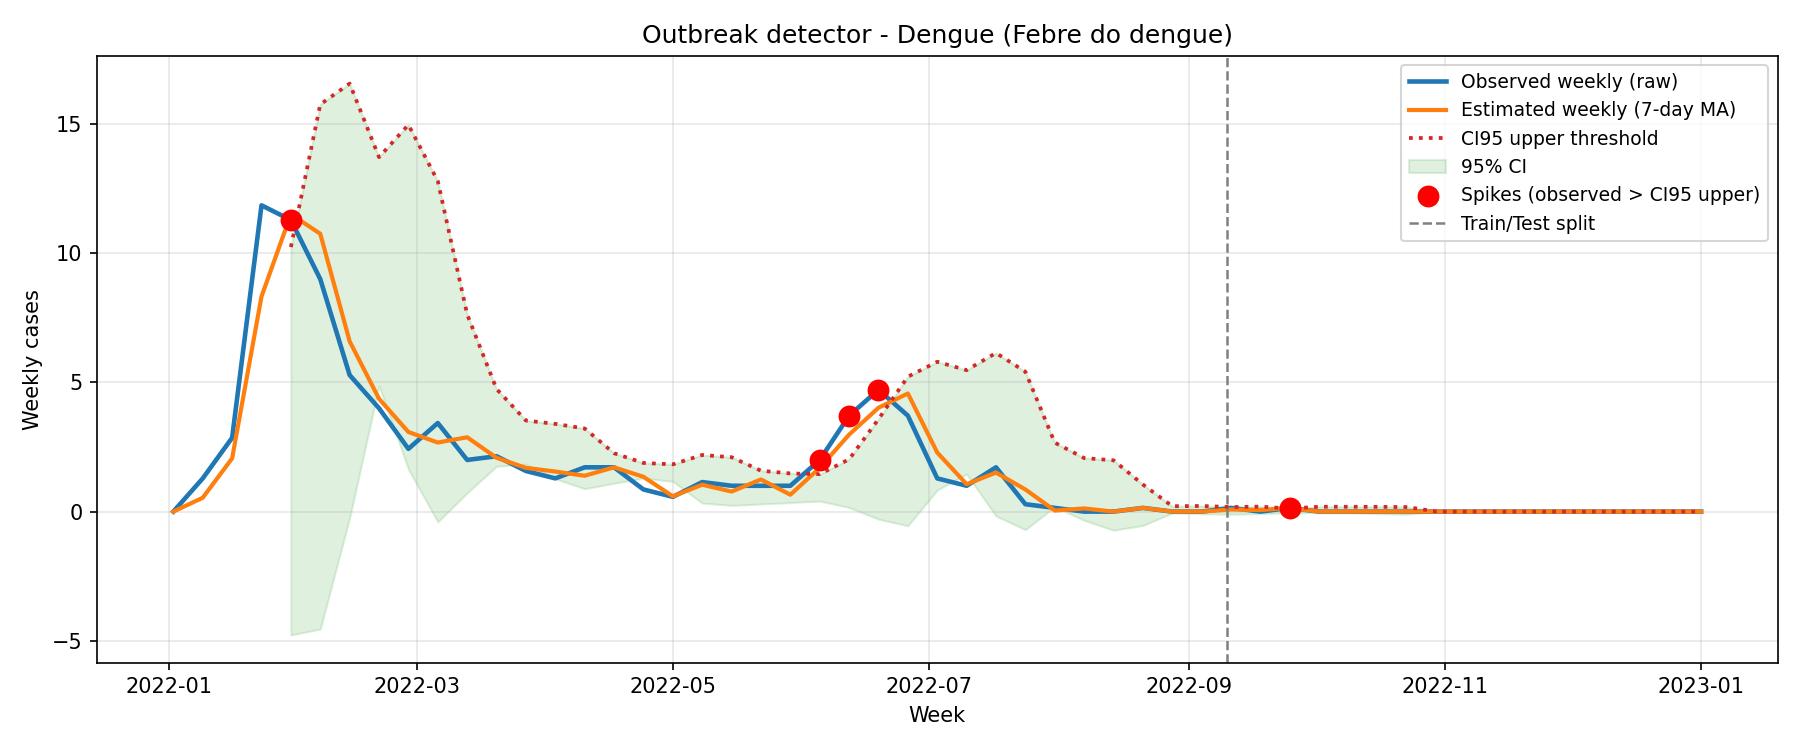

- influenza: /Users/daniellybx/Documents/Projeto Guardiões da Saúde - ProEpi /projeto_proepi_gds_datascience/data/results/time_series_outputs/charts/influenza_Gripe_outbreak_spikes.png


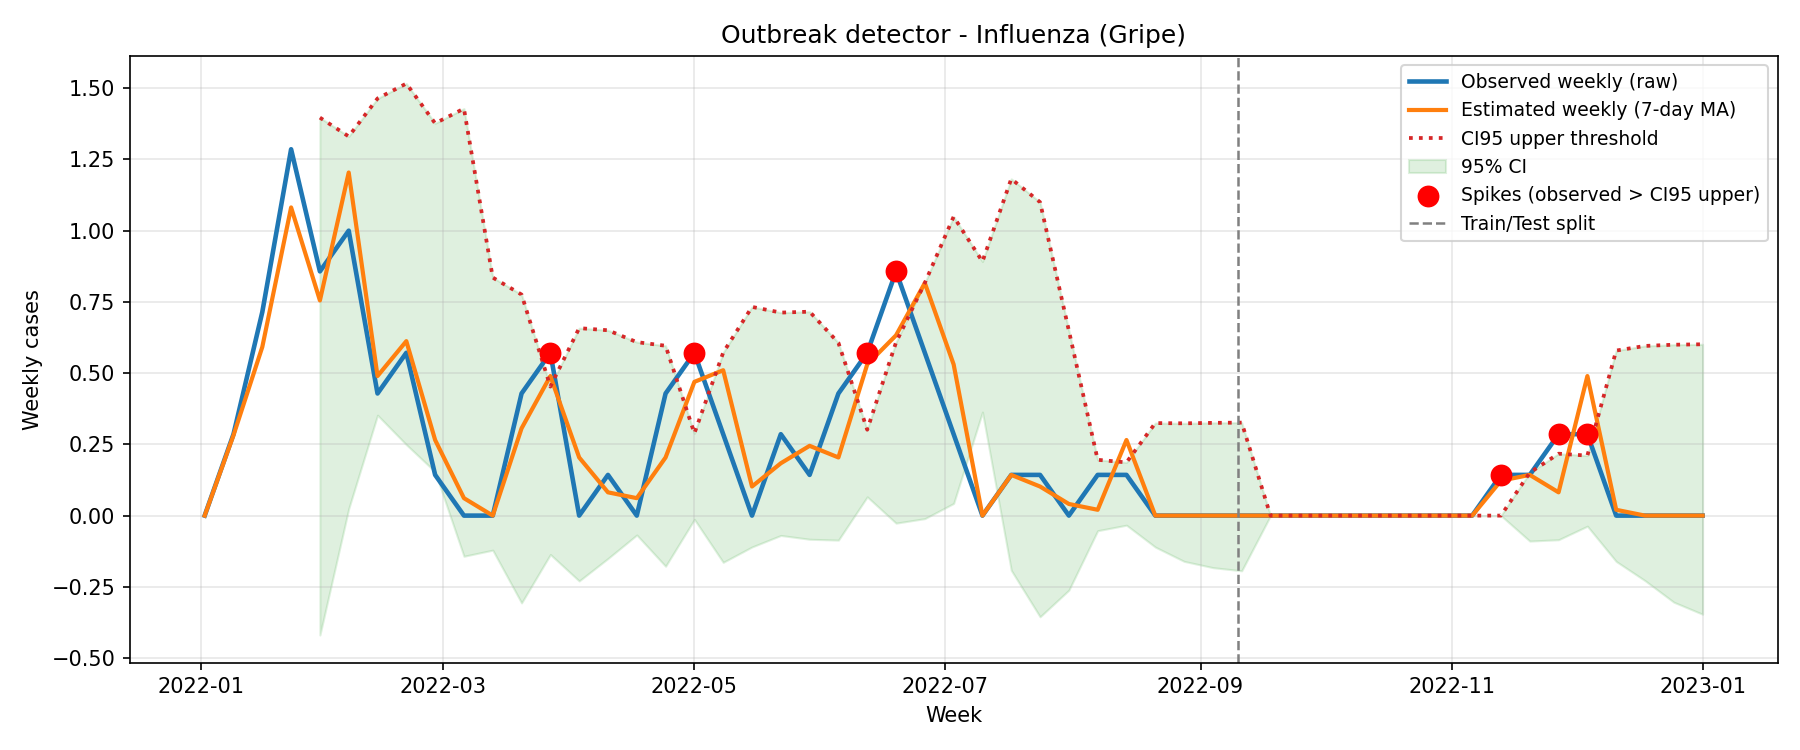

In [15]:
from IPython.display import Image, display

chart_groups = ["dengue", "influenza"]
chart_rows = summary_outbreak[summary_outbreak["group"].isin(chart_groups)].copy()

print("Charts de dengue e influenza:")
for _, row in chart_rows.iterrows():
    chart_path = Path(row["chart_path"])
    print(f"- {row['group']}: {chart_path}")
    if chart_path.exists():
        display(Image(filename=str(chart_path)))
    else:
        print("  Arquivo de chart não encontrado.")